## 📚 Import Libraries

In [2]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Preprocessing and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report,roc_auc_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# XGBoost
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

## 📂 Load Dataset

In [3]:
df = pd.read_csv('OnlineRetail_2.csv', encoding='latin-1')

In [4]:
df.head(6)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,01-12-2010 08:26,7.65,17850.0,United Kingdom


In [5]:
df.shape

(541909, 8)

In [6]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


## 🧹 Data Preprocessing

In [8]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(5268)

In [10]:
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.dropna(subset=['Description'], inplace=True)

In [13]:

df['Description'] = df['Description'].astype('category')
df['Country'] = df['Country'].astype('category')

In [14]:
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 524878 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype   
---  ------       --------------   -----   
 0   InvoiceNo    524878 non-null  object  
 1   StockCode    524878 non-null  object  
 2   Description  524878 non-null  category
 3   Quantity     524878 non-null  int64   
 4   InvoiceDate  524878 non-null  object  
 5   UnitPrice    524878 non-null  float64 
 6   CustomerID   392692 non-null  float64 
 7   Country      524878 non-null  category
dtypes: category(2), float64(2), int64(1), object(3)
memory usage: 29.7+ MB


In [16]:
scaler = MinMaxScaler()
df[['Quantity', 'UnitPrice']] = scaler.fit_transform(df[['Quantity', 'UnitPrice']])

In [17]:
Q1 = df['Quantity'].quantile(0.25)
Q3 = df['Quantity'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

## 📊 Exploratory Data Analysis (EDA)

(array([5.24867e+05, 9.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 1.00000e+00, 0.00000e+00, 1.00000e+00]),
 array([0.        , 0.03333333, 0.06666667, 0.1       , 0.13333333,
        0.16666667, 0.2       , 0.23333333, 0.26666667, 0.3       ,
        0.33333333, 0.36666667, 0.4       , 0.43333333, 0.46666667,
        0.5       , 0.53333333, 0.56666667, 0.6       , 0.63333333,
        0.66666667, 0.7       , 0.73333333, 0.76666667, 0.8       ,
        0.83333333, 0.86666667, 0.9       , 0.93333333, 0.96666667,
        1.        ]),
 <BarContainer object of 30 artists>)

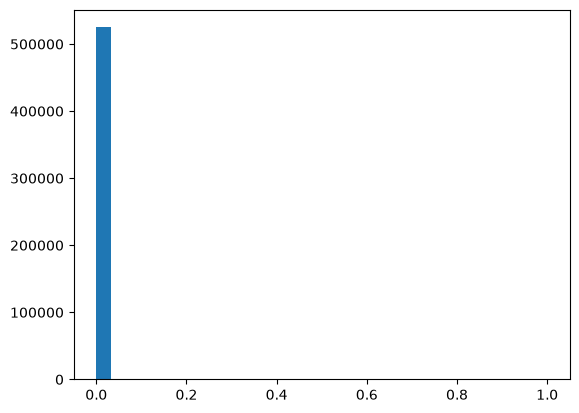

In [18]:
plt.hist(df['Quantity'], bins=30)

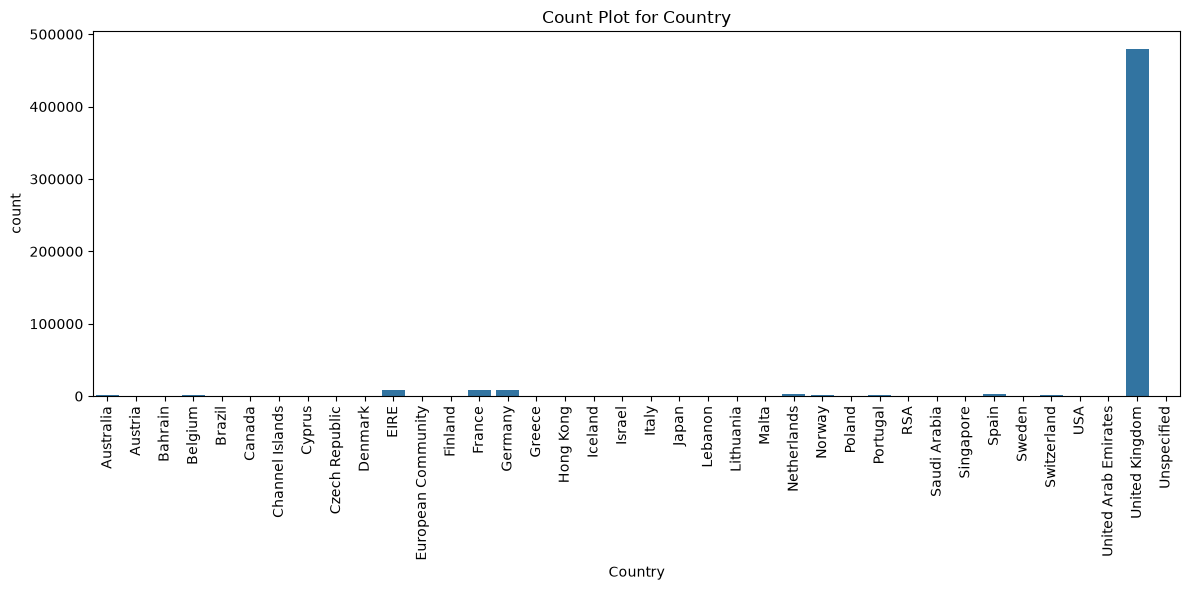

In [19]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Country')
plt.title('Count Plot for Country')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

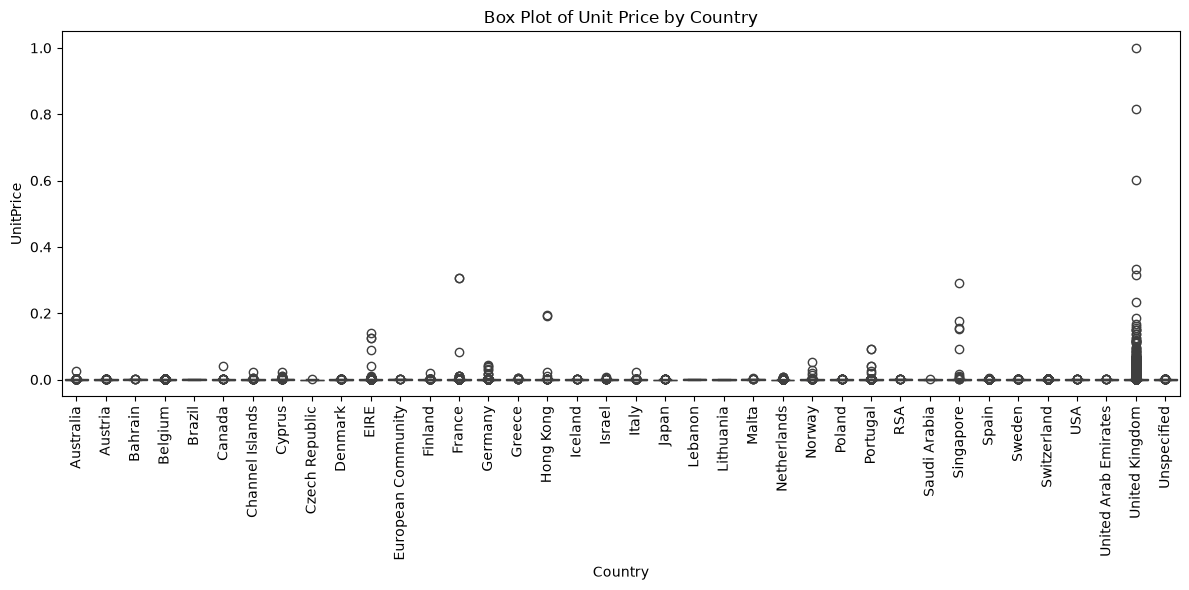

In [20]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Country', y='UnitPrice')
plt.title('Box Plot of Unit Price by Country')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

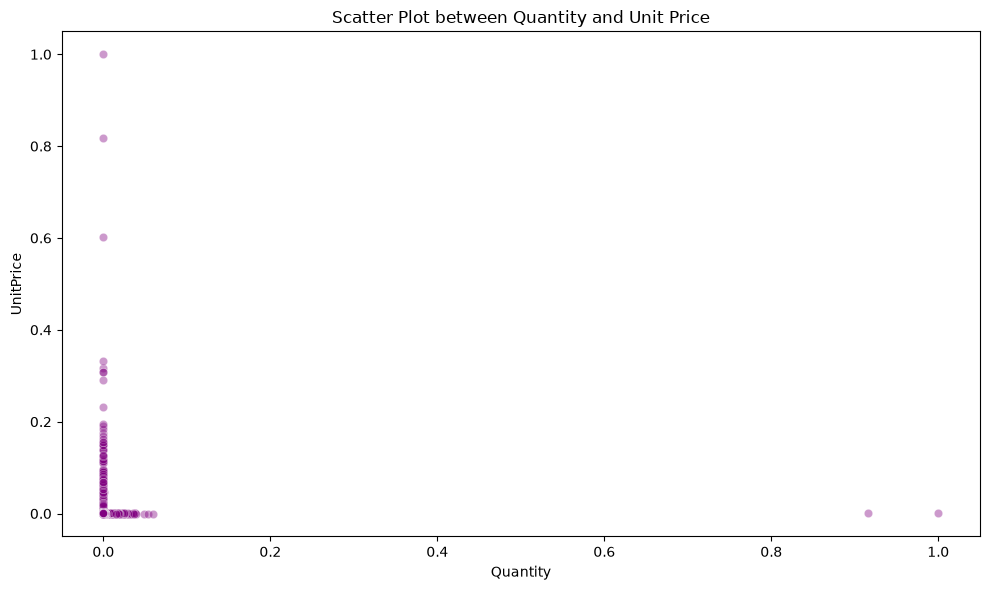

In [21]:
# Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Quantity', y='UnitPrice', alpha=0.4,color ='purple')
plt.title('Scatter Plot between Quantity and Unit Price')

plt.tight_layout()
plt.show()


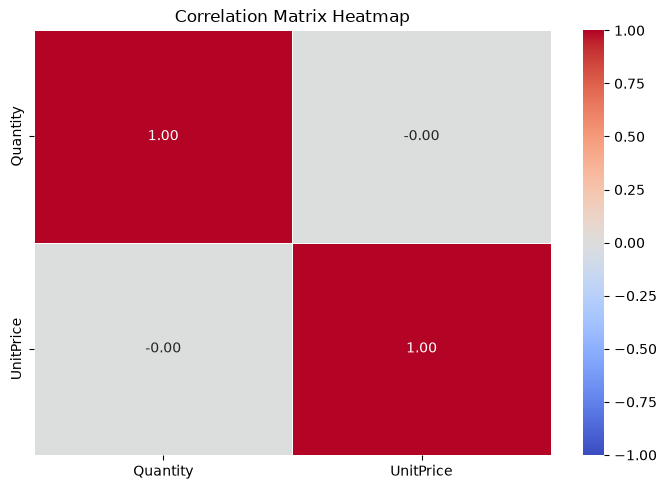

In [22]:
plt.figure(figsize=(7, 5))
numeric_features = df[['Quantity', 'UnitPrice']]
correlation_matrix = numeric_features.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix Heatmap')

plt.tight_layout()
plt.show()

## Creating New Features & Removing Unnecessary Columns 

In [23]:
# Ensure InvoiceDate is explicitly in datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

# 1. Create Line-Item Level Features
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

# Extract temporal patterns from the timestamp
df['InvoiceHour'] = df['InvoiceDate'].dt.hour
df['InvoiceDayOfWeek'] = df['InvoiceDate'].dt.dayofweek
df['InvoiceMonth'] = df['InvoiceDate'].dt.month
columns_to_drop = ['Description', 'InvoiceNo', 'StockCode']
df_feature_engineered = df.drop(columns=columns_to_drop)

print("--- Dataframe After Basic Feature Transformations ---")
print(df_feature_engineered.head())

--- Dataframe After Basic Feature Transformations ---
   Quantity         InvoiceDate  UnitPrice  CustomerID         Country  \
0  0.000062 2010-01-12 08:26:00   0.000188     17850.0  United Kingdom   
1  0.000062 2010-01-12 08:26:00   0.000250     17850.0  United Kingdom   
2  0.000086 2010-01-12 08:26:00   0.000203     17850.0  United Kingdom   
3  0.000062 2010-01-12 08:26:00   0.000250     17850.0  United Kingdom   
4  0.000062 2010-01-12 08:26:00   0.000250     17850.0  United Kingdom   

    TotalAmount  InvoiceHour  InvoiceDayOfWeek  InvoiceMonth  
0  1.162052e-08          8.0               1.0           1.0  
1  1.544996e-08          8.0               1.0           1.0  
2  1.754521e-08          8.0               1.0           1.0  
3  1.544996e-08          8.0               1.0           1.0  
4  1.544996e-08          8.0               1.0           1.0  


In [24]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], dayfirst=True, errors='coerce')
df = df.dropna(subset=['InvoiceDate'])

snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

new_data = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'Quantity': ['sum', 'mean'],                             # Volume
    'UnitPrice': 'mean',                                     # Ticket Sizes
    'TotalAmount': 'sum'                                     # Gross Revenue
}).reset_index()

new_data.columns = ['CustomerID', 'Recency_Days', 'Total_Quantity', 'Avg_Quantity', 'Avg_UnitPrice', 'Total_Spend']

# 5. Build binary classification targets
median_spend = new_data['Total_Spend'].median()
new_data['HighValueCustomer'] = (new_data['Total_Spend'] > median_spend).astype(int)

print("--- Missing Values Verification ---")
print(new_data.isnull().sum())
print(f"\nTotal clean unique customers ready for training: {new_data.shape[0]}")

--- Missing Values Verification ---
CustomerID           0
Recency_Days         0
Total_Quantity       0
Avg_Quantity         0
Avg_UnitPrice        0
Total_Spend          0
HighValueCustomer    0
dtype: int64

Total clean unique customers ready for training: 2997


##  Model Training

### Train and Test, Split

In [25]:
X = new_data[['Recency_Days', 'Total_Quantity', 'Avg_Quantity', 'Avg_UnitPrice']]
y = new_data['HighValueCustomer']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2, random_state=42, stratify=y)

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


In [26]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)


In [ ]:
clfs = {
    'SVC.................' : svc,
    'KN..................' : knc, 
    'DT..................' : dtc, 
    'LR..................' : lrc, 
    'RF..................' : rfc,
    'xgb.................' : xgb
}

In [32]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    recall = recall_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)
    auc = roc_auc_score(y_test,y_pred)
    confusion = confusion_matrix(y_test,y_pred)
    
    return accuracy,precision,recall,f1,auc,confusion


In [33]:
train_classifier(svc,X_train,y_train,X_test,y_test)


(0.52,
 0.8333333333333334,
 0.05,
 0.09433962264150944,
 0.52,
 array([[297,   3],
        [285,  15]]))

In [36]:
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []
auc_scores =[]
confusion = []


for name,clf in clfs.items():
    
    current_accuracy,current_precision,current_recall, current_f1 , current_roc_auc_score, current_confution_matrix = train_classifier(clf, X_train,y_train,X_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    print("Recall - ", current_recall)
    print("F1 - ", current_f1)
    print("Roc_auc - ",current_roc_auc_score)
    print("confusion_matrix - ")
    print(current_confution_matrix)


    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)
    recall_scores.append(current_recall)
    f1_scores.append(current_f1)
    auc_scores.append(current_roc_auc_score)
    confusion.append(current_confution_matrix)

For  SVC....................
Accuracy -  0.52
Precision -  0.8333333333333334
Recall -  0.05
F1 -  0.09433962264150944
Roc_auc -  0.52
confusion_matrix - 
[[297   3]
 [285  15]]
For  KN.....................
Accuracy -  0.845
Precision -  0.8736462093862816
Recall -  0.8066666666666666
F1 -  0.8388214904679376
Roc_auc -  0.845
confusion_matrix - 
[[265  35]
 [ 58 242]]
For  DT.....................
Accuracy -  0.915
Precision -  0.9108910891089109
Recall -  0.92
F1 -  0.9154228855721394
Roc_auc -  0.915
confusion_matrix - 
[[273  27]
 [ 24 276]]
For  LR.....................
Accuracy -  0.8616666666666667
Precision -  0.9003690036900369
Recall -  0.8133333333333334
F1 -  0.8546409807355516
Roc_auc -  0.8616666666666667
confusion_matrix - 
[[273  27]
 [ 56 244]]
For  RF.....................
Accuracy -  0.9116666666666666
Precision -  0.9102990033222591
Recall -  0.9133333333333333
F1 -  0.9118136439267887
Roc_auc -  0.9116666666666667
confusion_matrix - 
[[273  27]
 [ 26 274]]
For  xgb....

## Model Comparison

In [37]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores, 'Recall':recall_scores, 'F1':f1_scores, 'ROC':auc_scores}).sort_values('Precision',ascending=False)

In [38]:
performance_df

,Algorithm,Accuracy,Precision,Recall,F1,ROC
2,DT.....................,0.915000,0.910891,0.920000,0.915423,0.915000
4,RF.....................,0.911667,0.910299,0.913333,0.911814,0.911667
3,LR.....................,0.861667,0.900369,0.813333,0.854641,0.861667
5,xgb....................,0.910000,0.889241,0.936667,0.912338,0.910000
1,KN.....................,0.845000,0.873646,0.806667,0.838821,0.845000
0,SVC....................,0.520000,0.833333,0.050000,0.094340,0.520000


In [39]:
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")

In [40]:
performance_df1

,Algorithm,variable,value
0,DT.....................,Accuracy,0.915000
1,RF.....................,Accuracy,0.911667
2,LR.....................,Accuracy,0.861667
3,xgb....................,Accuracy,0.910000
4,KN.....................,Accuracy,0.845000
5,SVC....................,Accuracy,0.520000
6,DT.....................,Precision,0.910891
7,RF.....................,Precision,0.910299
8,LR.....................,Precision,0.900369
9,xgb....................,Precision,0.889241


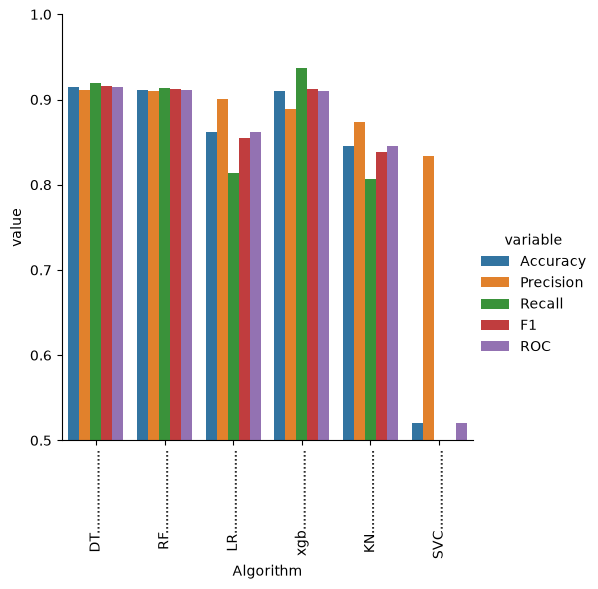

In [41]:
sns.catplot(x = 'Algorithm', y='value', 
               hue = 'variable',data=performance_df1, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()